## Permisos Google colab

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

## Importar librerias que vamos a usar

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [22]:
s1=pd.Series([50,52,48,55,53,49,51])
n1=s1.to_numpy()
print(type(n1))

<class 'numpy.ndarray'>


In [20]:
n1.std()

np.float64(2.2314999074019015)

## Leer archivo, construir el dataframe y mostralo

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df = pd.read_csv('/content/drive/MyDrive/Bedu Ciencia de datos/Modulo3_Análisis_de_datos_con_Python/proyecto Modulo 3/possible linear regression projects/youtube_AlejandroAO_LinearRegresion/Ecommerce Customers')
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


## Explorando el dataFrame

In [23]:
df.shape

(500, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [ ]:
df.isna().sum()

Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

## Datos estadísticos

In [ ]:
df.columns

Index(['Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership', 'Yearly Amount Spent'],
      dtype='object')

In [ ]:
print(f"""
Columna 'Avg. Session Length' :\n
    promedio de la sesion: {df['Avg. Session Length'].mean()}\n
    mediana de la sesion:  {df['Avg. Session Length'].median()}\n
    rango de 'Avg. Session Length': {df['Avg. Session Length'].max()-df['Avg. Session Length'].min()}\n
Columna 'Time on App' :\n
    promedio de la sesion: {df['Time on App'].mean()}\n
    mediana de la sesion:  {df['Time on App'].median()}\n
    rango de 'Time on App': {df['Time on App'].max()-df['Time on App'].min()}\n
Columna 'Time on Website' :\n
    promedio de la sesion: {df['Time on Website'].mean()}\n
    mediana de la sesion:  {df['Time on Website'].median()}\n
    rango de 'Time on Website': {df['Time on Website'].max()-df['Time on Website'].min()}\n
Columna 'Length of Membership' :\n
    promedio de la sesion: {df['Length of Membership'].mean()}\n
    mediana de la sesion:  {df['Length of Membership'].median()}\n
    rango de 'Length of Membership': {df['Length of Membership'].max()-df['Length of Membership'].min()}\n
Columna 'Yearly Amount Spent' :\n
    promedio del gasto: {df['Yearly Amount Spent'].mean()}\n
    mediana del gasto:  {df['Yearly Amount Spent'].median()}\n
    rango de 'Yearly Amount Spent': {df['Yearly Amount Spent'].max()-df['Yearly Amount Spent'].min()}\n
""")



Columna 'Avg. Session Length' :

    promedio de la sesion: 33.05319351819619

    mediana de la sesion:  33.08200760262899

    rango de 'Avg. Session Length': 6.607233521732578

Columna 'Time on App' :

    promedio de la sesion: 12.052487937166132

    mediana de la sesion:  11.983231258825267

    rango de 'Time on App': 6.618842112759866

Columna 'Time on Website' :

    promedio de la sesion: 37.06044542094858

    mediana de la sesion:  37.069366582835826

    rango de 'Time on Website': 6.091334390517254

Columna 'Length of Membership' :

    promedio de la sesion: 3.5334615559150566

    mediana de la sesion:  3.5339750035877096

    rango de 'Length of Membership': 6.652788245051533

Columna 'Yearly Amount Spent' :

    promedio del gasto: 499.31403825859053

    mediana del gasto:  498.887875469115

    rango de 'Yearly Amount Spent': 508.8478796487813




## Entendiendo la distribucion de los datos

In [ ]:
print(f"""
Varianza de datos en columna 'Avg. Session Length' :  {df['Avg. Session Length'].var()}\n
Varianza de datos en columna 'Time on App' :          {df['Time on App'].var()}\n
Varianza de datos en columna 'Time on Website' :      {df['Time on Website'].var()}\n
Varianza de datos en columna 'Length of Membership' : {df['Length of Membership'].var()}\n
Varianza de datos en columna'Yearly Amount Spent' :   {df['Yearly Amount Spent'].var()}
""")


Varianza de datos en columna 'Avg. Session Length' :  0.9851815294858118

Varianza de datos en columna 'Time on App' :          0.9884646761304277

Varianza de datos en columna 'Time on Website' :      1.0210878306777482

Varianza de datos en columna 'Length of Membership' : 0.998555526825282

Varianza de datos en columna'Yearly Amount Spent' :   6290.834572277705



In [ ]:
print(f"""
Desviación estandar de datos en columna 'Avg. Session Length' : {df['Avg. Session Length'].std()}\n
Desviación estandar de datos en columna 'Time on App' :         {df['Time on App'].std()}\n
Desviación estandar de datos en columna 'Time on Website' :     {df['Time on Website'].std()}\n
Desviación estandar de datos en columna 'Length of Membership' :{df['Length of Membership'].std()}\n
Desviación estandar de datos en columna'Yearly Amount Spent' :  {df['Yearly Amount Spent'].std()}
""")


Desviación estandar de datos en columna 'Avg. Session Length' : 0.9925631110845354

Desviación estandar de datos en columna 'Time on App' :         0.9942156084725423

Desviación estandar de datos en columna 'Time on Website' :     1.0104889067564018

Desviación estandar de datos en columna 'Length of Membership' :0.9992775024112581

Desviación estandar de datos en columna'Yearly Amount Spent' :  79.31478154970677



## Subplots con histogramas y gráficas de densidad

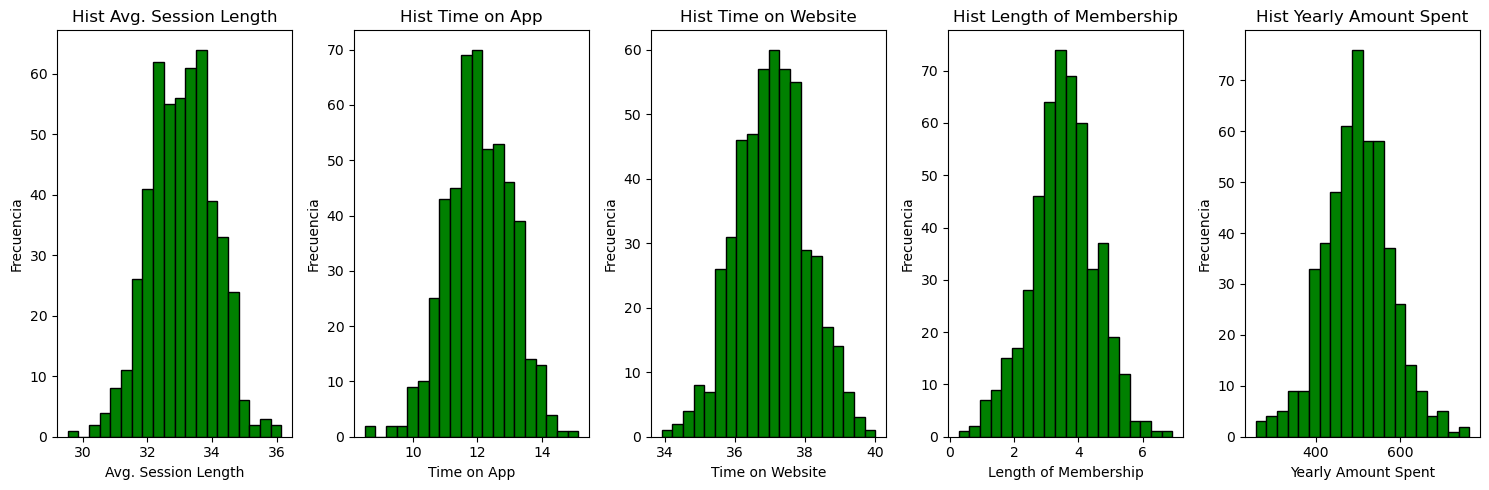

In [ ]:
columnas = ['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership','Yearly Amount Spent']

fig, axes = plt.subplots(1, 5, figsize=(15, 5))

# Iterar a través de las columnas y crear un histograma en cada subplot
for i, columna in enumerate(columnas):
    axes[i].hist(df[columna], bins=20,color ='green', edgecolor='black')
    axes[i].set_title(f'Hist {columna}')
    axes[i].set_xlabel(columna)
    axes[i].set_ylabel('Frecuencia')

# Ajustar el espaciado entre subplots para que no se superpongan
plt.tight_layout()

# Mostrar la gráfica
plt.show()

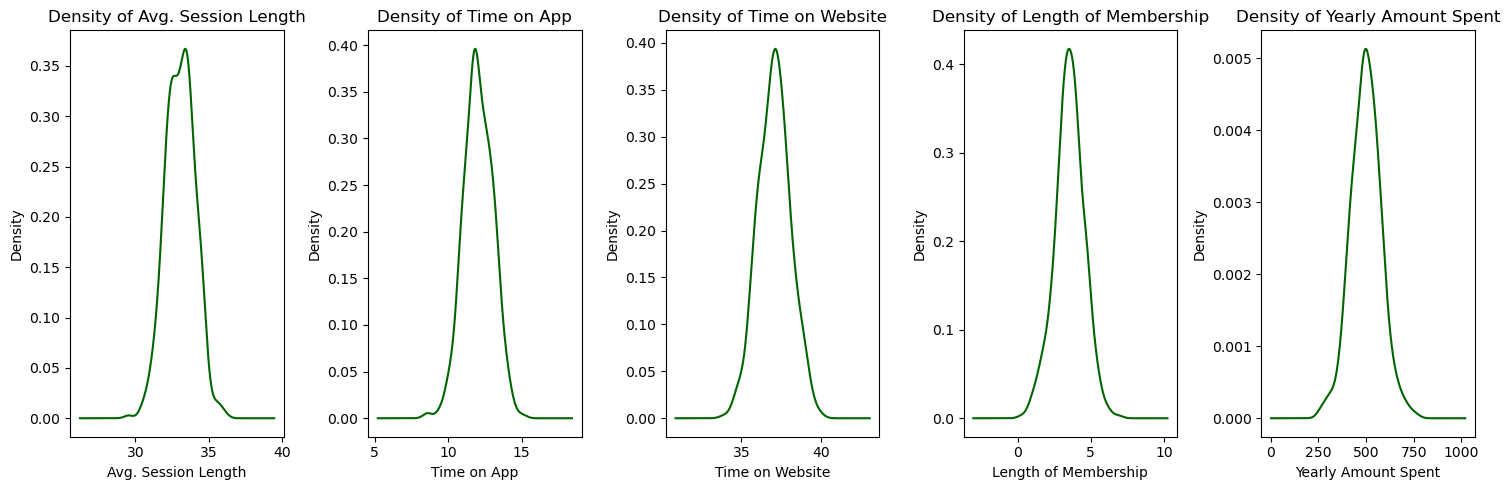

In [ ]:
columnas = ['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership','Yearly Amount Spent']

# Crear la figura y los subplots
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(15, 5))

# Iterar a través de las columnas y graficar la densidad en cada subplot
for i, columna in enumerate(columnas):
    # Usando Matplotlib
    df[columna].plot(kind='kde', ax=axes[i], color='darkgreen')
    axes[i].set_title(f'Density of {columna}')
    axes[i].set_xlabel(columna)
    axes[i].set_ylabel('Density')

    # sns.kdeplot(df[columna], ax=axes[i], fill=True)
    # axes[i].set_title(f'Densidad de {columna}')
    # axes[i].set_xlabel(columna)
    # axes[i].set_ylabel('Densidad')

plt.tight_layout() # Ajusta el espaciado entre subplots para evitar superposiciones
plt.show()

## Matriz de correlacion

In [6]:
#Crear un dataframe solo con valores cuantitativos
df_correlacion = df.filter(['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership', 'Yearly Amount Spent'], axis =1 )
df_correlacion.head()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,34.497268,12.655651,39.577668,4.082621,587.951054
1,31.926272,11.109461,37.268959,2.664034,392.204933
2,33.000915,11.330278,37.110597,4.104543,487.547505
3,34.305557,13.717514,36.721283,3.120179,581.852344
4,33.330673,12.795189,37.536653,4.446308,599.406092


In [7]:
correlation_matrix = df_correlacion.corr()
correlation_matrix.head()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
Avg. Session Length,1.000000,-0.027826,-0.034987,0.060247,0.355088
Time on App,-0.027826,1.000000,0.082388,0.029143,0.499328
Time on Website,-0.034987,0.082388,1.000000,-0.047582,-0.002641
Length of Membership,0.060247,0.029143,-0.047582,1.000000,0.809084
Yearly Amount Spent,0.355088,0.499328,-0.002641,0.809084,1.000000


## coeficiente de pearson

In [ ]:
# Calcular el coeficiente de correlación de Pearson
pearson_corr, pval = pearsonr(df['Length of Membership'], df['Yearly Amount Spent'])
print(f"Coeficiente de correlación de Pearson: {pearson_corr:.2f}; valor pvalue : {pval:.2f}")

Coeficiente de correlación de Pearson: 0.81; valor pvalue : 0.00


## Mapa de calor

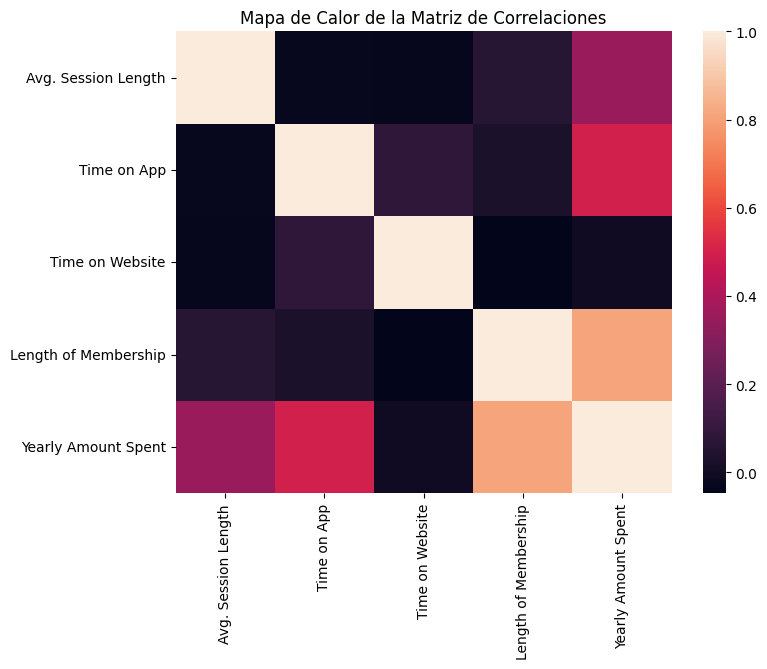

In [8]:
# Crear el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix)#, annot=True, cmap='coolwarm', linewidths=1

# Titulo y mostrar gráfico
plt.title('Mapa de Calor de la Matriz de Correlaciones')
plt.show()

## Pairplot

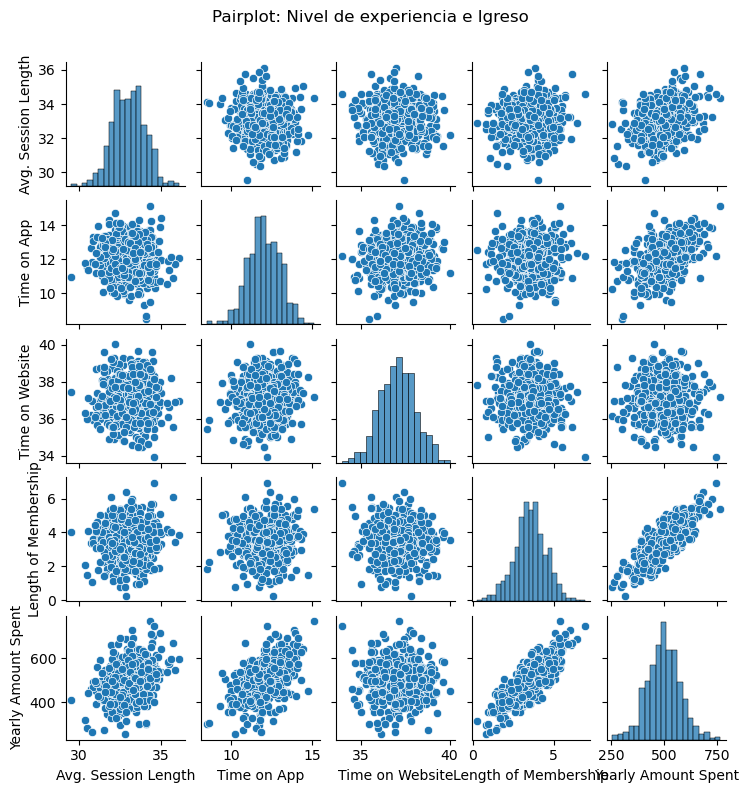

In [ ]:
# Crear el pairplot
sns.pairplot(df, height=1.5)
# Personalizar y mostrar el gráfico
plt.suptitle('Pairplot: Nivel de experiencia e Igreso', y=1.05)
plt.show()

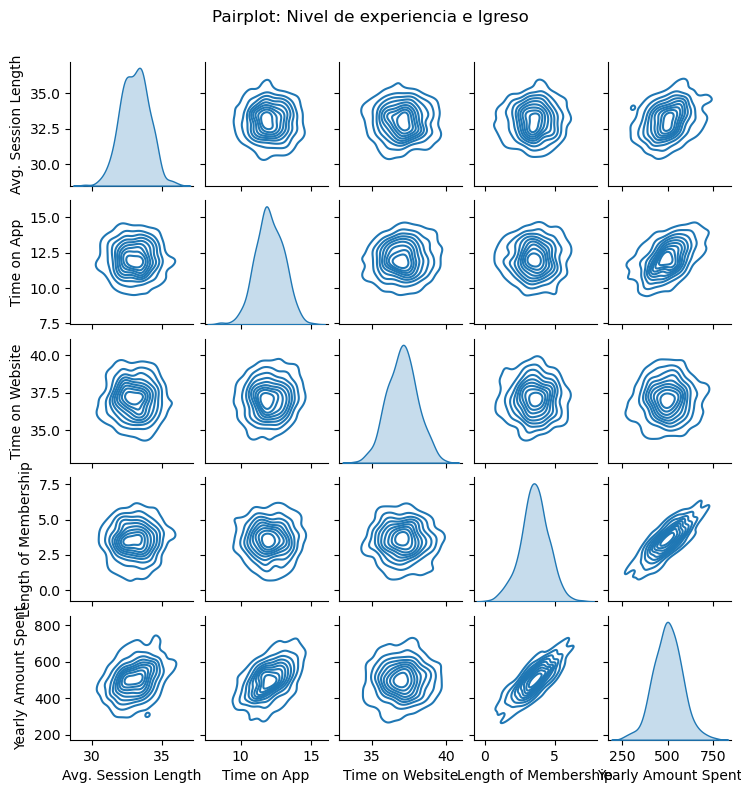

In [ ]:
# Crear el pairplot
sns.pairplot(df, kind='kde', height=1.5)
# Personalizar y mostrar el gráfico
plt.suptitle('Pairplot: Nivel de experiencia e Igreso', y=1.05)
plt.show()

## Scatterplot

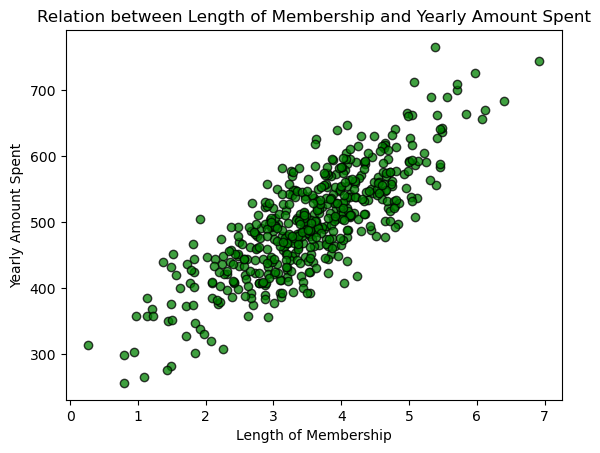

In [ ]:
# Crear el scatterplot
plt.scatter(df['Length of Membership'], df['Yearly Amount Spent'], color='green', edgecolors='black', alpha=0.75)

# Personalizar el gráfico
plt.title('Relation between Length of Membership and Yearly Amount Spent')
plt.xlabel('Length of Membership')
plt.ylabel('Yearly Amount Spent')
plt.grid(False)
plt.show()

## Regresion lineal simple

In [ ]:
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [ ]:
df.columns

Index(['Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership', 'Yearly Amount Spent'],
      dtype='object')

In [ ]:
# Definir las variables independientes (X) y dependiente (y)
X = df[['Length of Membership']]
y = df['Yearly Amount Spent']

# Crear una instancia del modelo de regresión lineal
model = LinearRegression()

# Ajustar el modelo a los datos
model.fit(X, y)

# Obtener los coeficientes del modelo
coeficiente = model.coef_[0]
intercepto = model.intercept_

# Mostrar la ecuación de la regresión lineal
print(f"Ecuación de la regresión lineal: y = {coeficiente:.2f}x + {intercepto:.2f}")

Ecuación de la regresión lineal: y = 64.22x + 272.40


In [ ]:
print(y)

     Yearly Amount Spent
0             587.951054
1             392.204933
2             487.547505
3             581.852344
4             599.406092
..                   ...
495           573.847438
496           529.049004
497           551.620145
498           456.469510
499           497.778642

[500 rows x 1 columns]


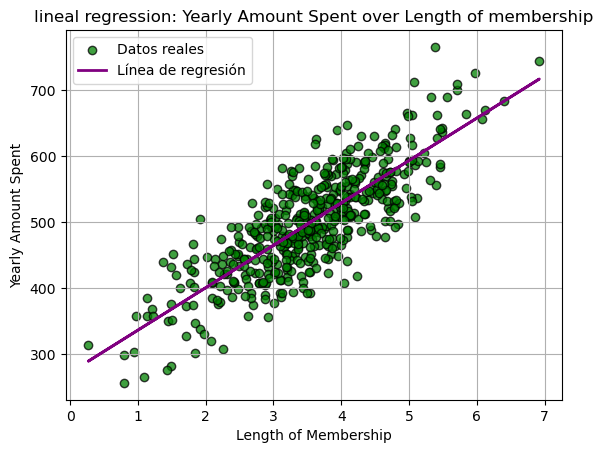

In [ ]:
# Visualizar los resultados
plt.scatter(X, y, color='green', edgecolors='black' , alpha=0.75 ,label='Datos reales')
plt.plot(X, model.predict(X), color='purple', linewidth=2, label='Línea de regresión')
plt.title('lineal regression: Yearly Amount Spent over Length of membership')
plt.xlabel('Length of Membership')
plt.ylabel('Yearly Amount Spent')
plt.legend()
plt.grid(True)
plt.show()

## Evaluacion del modelo separando poblaciones de entrenamiento(70%) y prueba(30%)

In [ ]:
#agregamos la librerioa para entrenar y probar nuestro modelo
from sklearn.model_selection import train_test_split

In [ ]:
# Definir las variables independientes (X) y dependiente (y)
X = df[['Length of Membership']]
y = df['Yearly Amount Spent']

# Dividir los datos en conjunto de entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, )#remove this code ->stratify=y

# Mostrar la forma de los conjuntos para confirmar la división
print(f"Conjunto de Entrenamiento: {X_train.shape}, {y_train.shape}")
print(f"Conjunto de Prueba: {X_test.shape}, {y_test.shape}")

Conjunto de Entrenamiento: (350, 1), (350,)
Conjunto de Prueba: (150, 1), (150,)


## Arbol de desición

In [ ]:
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092
